<a href="https://colab.research.google.com/github/aasimusman1212-cyber/basics-of-ml/blob/main/clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1
import pandas as pd

In [ ]:
#2
iris =pd.read_csv("/content/iris.csv")
print("iris dataset loaded successfully")

iris dataset loaded successfully


In [ ]:
#3
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species_number,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
#4
iris.tail()

,sepal_length,sepal_width,petal_length,petal_width,species_number,species
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


In [ ]:
#5iris.shape

In [ ]:
#6
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sepal_length    150 non-null    float64
 1   sepal_width     150 non-null    float64
 2   petal_length    150 non-null    float64
 3   petal_width     150 non-null    float64
 4   species_number  150 non-null    int64  
 5   species         150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
#7
iris.dtypes

,0
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
species_number,int64
species,object


In [ ]:
#8
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width,species_number
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [ ]:
iris.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species_number,0
species,0


In [ ]:
iris_features = iris[
[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
   ]
].copy()
iris_features.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


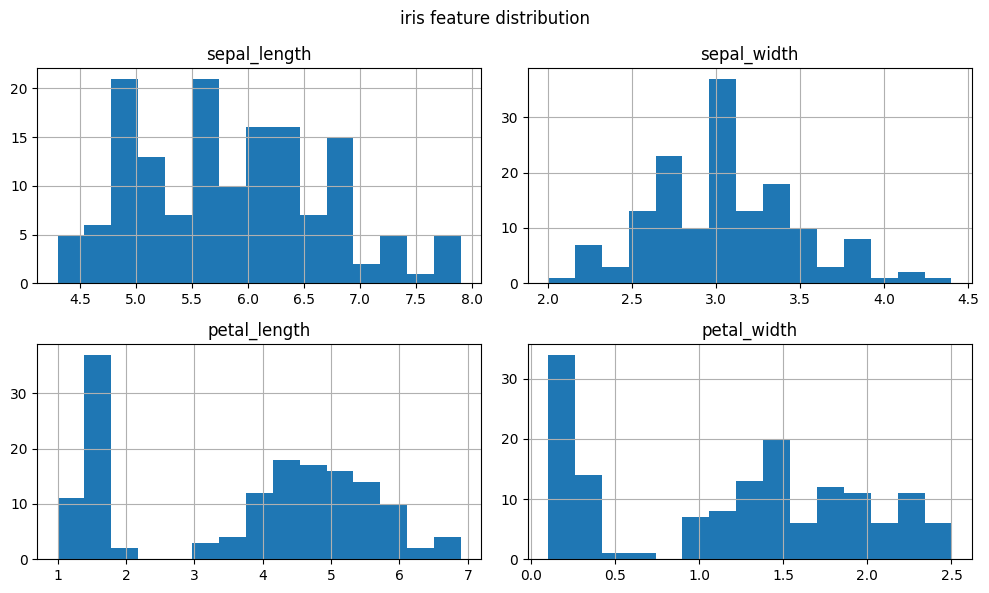

In [ ]:
import matplotlib.pyplot as plt
iris_features.hist(
    bins=15,
    figsize=(10,6)
)

plt.suptitle("iris feature distribution")
plt.tight_layout()
plt.show()

In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
iris_scaler = scaler.fit_transform(
    iris_features
)

In [58]:
from sklearn.cluster import KMeans
inertia_values = []
for k in range(1,11):
  model = KMeans(
      n_clusters=k,
      random_state=42,
      n_init=10 # Corrected from n_int to n_init
  )
  model.fit(iris_scaler)
  inertia_values.append(model.inertia_)


In [59]:
kMeans_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
iris_clusters = kMeans_model.fit_predict(
    iris_scaler
)

In [46]:
iris_clustered = iris.copy()
iris_clustered["cluster"] = iris_clusters
iris_clustered.head()

,sepal_length,sepal_width,petal_length,petal_width,species_number,species,cluster
0,5.1,3.5,1.4,0.2,0,setosa,1
1,4.9,3.0,1.4,0.2,0,setosa,1
2,4.7,3.2,1.3,0.2,0,setosa,1
3,4.6,3.1,1.5,0.2,0,setosa,1
4,5.0,3.6,1.4,0.2,0,setosa,1


In [60]:
# this is model evaluation
from sklearn.metrics import silhouette_score

score = silhouette_score(
    iris_scaler,
    iris_clusters
)

print("silhouette score :",score)


silhouette score : 0.45994823920518646


In [48]:
#prediction of the unknown data i.e custom data
new_flower = pd.DataFrame({
    "sepal_length":[5,8],
    "sepal_width":[2,7],
    "petal_length":[4,1],
    "petal_width":[1,0],
})
new_flower

,sepal_length,sepal_width,petal_length,petal_width
0,5,2,4,1
1,8,7,1,0


In [62]:
new_flower_scaled = scaler.transform(
    new_flower
)

In [64]:
flower_cluster = kMeans_model.predict(
new_flower_scaled
)[0]
print("predict cluster :", flower_cluster)

predict cluster : 0
